In [1]:
import copy
import snappy
import khovanov
import itertools
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from knot_graphs import *
from geography import *

In [5]:
def planar_band_targets(edge, planar_emb):
    face_nodes = planar_emb.traverse_face(edge[0], edge[1])
    return [(face_nodes[i], face_nodes[(i+1) % len(face_nodes)]) for i in range(len(face_nodes))]

def list_planar_arc_pairs(knot : snappy.Link):
    graph = adjacency_graph(knot)
    is_planar, planar_emb = nx.check_planarity(graph)
    if not is_planar:
        return "Knot graph isn't planar!"

    planar_band_arcs = {}
    for e in planar_emb.edges():
        planar_band_arcs[e] = planar_band_targets(e, planar_emb)[1:] # all other edges in the right face associated to e
    return planar_band_arcs

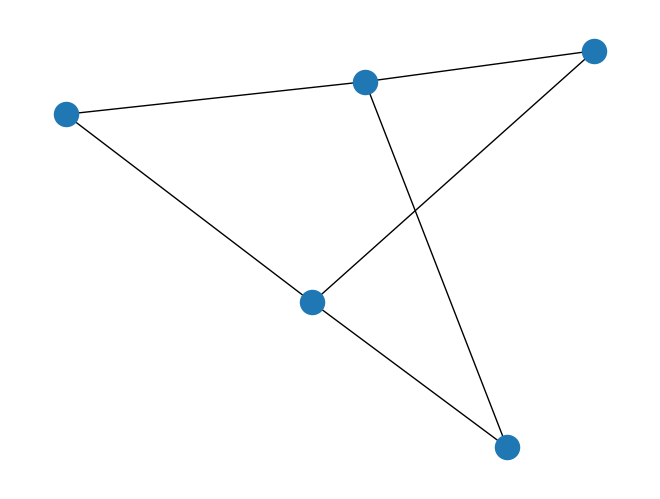

In [22]:
K_dual = K.dual_graph()
nx.draw(K.dual_graph().to_networkx())

In [21]:
K = snappy.Link("3_1")
list_planar_arc_pairs(K)

{(0, 2): [(2, 1), (1, 0)],
 (0, 1): [(1, 2), (2, 0)],
 (1, 2): [(2, 0), (0, 1)],
 (1, 0): [(0, 2), (2, 1)],
 (2, 0): [(0, 1), (1, 2)],
 (2, 1): [(1, 0), (0, 2)]}

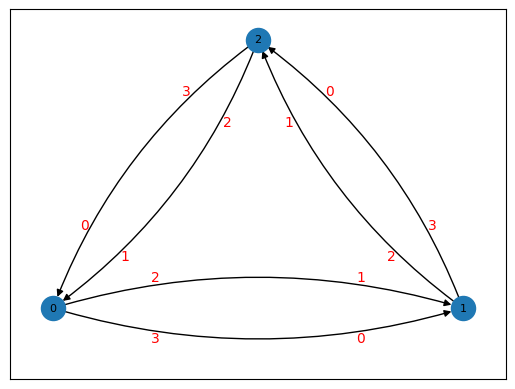

In [10]:
draw_adjacency_graph(K)

In [12]:
is_planar, planar_emb = nx.check_planarity(adjacency_graph(K))

In [17]:
print(planar_emb.nodes)
print(planar_emb.edges)

[0, 1, 2]
[(0, 2), (0, 1), (1, 2), (1, 0), (2, 0), (2, 1)]


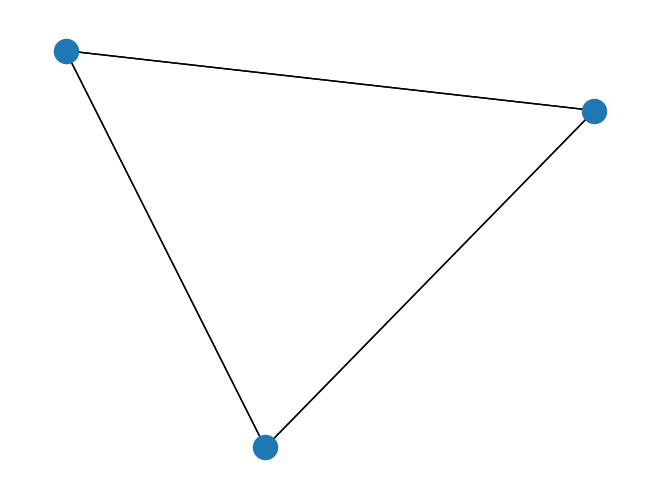

In [14]:
nx.draw(planar_emb)


In [51]:
def try_bands_helper(cob : khovanov.Cobordism, prev_bands : list, max_depth=5, return_cob=False):
    if len(prev_bands) == max_depth: return []

    # only get full Crossings, not CrossingStrands
    crossings = [c for c in cob.links[-1].crossings if len(c.adjacent) == 4]
    strands = [0,1,2,3]
    twists = [-1,0,1]
    cs_pairs = list(itertools.product(crossings, strands))

    results = []
    for twist in twists:
        for (c0,s0) in cs_pairs:
            for (c1, s1) in cs_pairs:
                if c0 == c1 and s0 == s1: continue

                cob_copy = copy.deepcopy(cob)
                try:
                    cob_copy.band_move(twist, (c0,s0), (c1,s1))
                    cob_copy.finish()
                except:
                    # if simplification fails then ignore this band
                    continue

                new_bands = prev_bands + [(twist, (c0,s0), (c1,s1))]

                # check if unknot reached
                if cob_copy.movie[-1][0] == 'morse_death' and len(cob_copy.links[-1].crossings) == 0:
                    if return_cob:
                        results.append((new_bands, cob_copy))
                    else: 
                        results.append(new_bands)
                else:
                    # try other bands
                    results.extend(try_bands_helper(cob_copy, new_bands, max_depth, return_cob))
    return results

def try_bands(knot : khovanov.Link, max_depth=5, return_cob=False):
    cob = khovanov.Cobordism(knot)
    return try_bands_helper(cob, [], max_depth, return_cob=return_cob)